### Imports e Configuração Inicial
Esta célula importa as bibliotecas necessárias para o projeto, como `numpy`, `pandas`, `torch`, `yfinance` e `matplotlib`. Também define sementes aleatórias para reprodutibilidade.

In [2]:
# =============================================================================
# Série Temporal com LSTM - PyTorch
# Ações: ITUB4, BBDC4, BBAS3, SANB11
# Período: 2010-2018
# =============================================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)

### Download de Dados Financeiros
Esta célula define os tickers das ações e moedas de interesse e utiliza a biblioteca `yfinance` para baixar os preços de fechamento históricos para o período de 2010 a 2018. Linhas com valores ausentes são removidas.

In [3]:
TICKERS = ["ITUB4.SA", "BBDC4.SA", "BBAS3.SA", "SANB11.SA", "^BVSP", "BRL=X"]
NOMES   = ["Itau", "Bradesco", "BB", "Santander", "IBOV", "DOLAR"]

df = yf.download(TICKERS, start="2010-01-01", end="2018-12-31")
df = df["Close"]
df.dropna(inplace=True)

/tmp/ipykernel_4699/3934357040.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKERS, start="2010-01-01", end="2018-12-31")
[*********************100%***********************]  6 of 6 completed


### Geração de Features
Esta célula calcula diversas features técnicas a partir dos preços de fechamento. Inclui retornos diários (`_Ret1`), retornos de 5 dias (`_Ret5`), momentum de 5 dias (`_Mom5`) para cada ativo, e spreads entre os preços dos bancos. Todas as linhas com valores ausentes são removidas após a criação das features.

In [4]:
df_features = pd.DataFrame(index=df.index)

for nome, ticker in zip(NOMES, TICKERS):
    close = df[ticker]

    df_features[f"{nome}_Ret1"] = close.pct_change()
    df_features[f"{nome}_Ret5"] = close.pct_change(5)
    df_features[f"{nome}_Mom5"] = close - close.shift(5)

# Spreads entre bancos
df_features["Spread_ITAU_BBDC"] = df["ITUB4.SA"] - df["BBDC4.SA"]
df_features["Spread_ITAU_BB"]   = df["ITUB4.SA"] - df["BBAS3.SA"]
df_features["Spread_BBDC_BB"]   = df["BBDC4.SA"] - df["BBAS3.SA"]

df_features.dropna(inplace=True)

### Definição do Target
Esta célula define a variável target (alvo) para o modelo. Para cada banco, ela calcula se o retorno acumulado nos próximos `HORIZONTE` (5) dias é maior que um `threshold` (0.02). O resultado é uma variável binária (0 ou 1).

In [5]:
HORIZONTE = 5
threshold = 0.02

targets = []

for nome in ["Itau", "Bradesco", "BB", "Santander"]:
    future_return = df_features[f"{nome}_Ret1"].rolling(HORIZONTE).sum().shift(-HORIZONTE)
    target = (future_return > threshold).astype(int)
    targets.append(target)

y = np.column_stack(targets)

df_features = df_features.iloc[:-HORIZONTE]
y = y[:-HORIZONTE]

### Configuração de Sequência e Divisão de Dados
Esta célula define o tamanho da sequência (`SEQ_LEN`) para a LSTM e a data (`SPLIT_DATE`) para dividir os dados em conjuntos de treino e teste. Ela também encontra o índice correspondente à data de divisão.

In [6]:
SEQ_LEN = 30
SPLIT_DATE = "2018-01-01"

datas = df_features.index

split_idx = np.searchsorted(datas, pd.Timestamp(SPLIT_DATE))

### Normalização dos Dados
Esta célula utiliza `MinMaxScaler` para normalizar as features. O scaler é ajustado (`fit`) apenas nos dados de treinamento (antes da data de split) para evitar vazamento de dados, e então aplicado (`transform`) a todo o conjunto de features.

In [7]:
scaler = MinMaxScaler()

#  só treino
scaler.fit(df_features.iloc[:split_idx])

data_scaled = scaler.transform(df_features)

### Criação de Sequências para LSTM
Esta célula define a função `create_sequences` para transformar os dados escalonados e o target em sequências de comprimento `SEQ_LEN`, adequadas para um modelo LSTM. Em seguida, divide essas sequências em conjuntos de treinamento e teste.

In [8]:
def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(data_scaled, y, SEQ_LEN)

datas_seq = datas[SEQ_LEN:]
split_seq = np.searchsorted(datas_seq, pd.Timestamp(SPLIT_DATE))

X_train, X_test = X_seq[:split_seq], X_seq[split_seq:]
y_train, y_test = y_seq[:split_seq], y_seq[split_seq:]

### Preparação dos Dados para PyTorch
Esta célula converte os arrays numpy de treinamento e teste em tensores PyTorch (`FloatTensor`) e cria `DataLoader`s. Os `DataLoader`s facilitam o carregamento de dados em lotes (batches) durante o treinamento do modelo.

In [9]:
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)

X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.FloatTensor(y_test)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

### Definição do Modelo LSTM
Esta célula define a arquitetura da rede neural LSTM. A classe `LSTMModel` herda de `nn.Module` e contém camadas LSTM, Dropout e uma camada linear seguida por uma função de ativação Sigmoid para a saída binária.

In [10]:
class LSTMModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.lstm = nn.LSTM(input_size, 128, num_layers=2, batch_first=True, dropout=0.3)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(128, 4)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        h0 = torch.zeros(2, x.size(0), 128)
        c0 = torch.zeros(2, x.size(0), 128)

        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.sigmoid(self.fc(out))
        return out

model = LSTMModel(X_train.shape[2])

### Treinamento do Modelo LSTM
Esta célula configura a função de perda (`BCELoss` para classificação binária), o otimizador (`Adam`) e o número de épocas (`EPOCHS`). Em seguida, executa o loop de treinamento, calculando e exibindo a perda de treinamento e validação a cada 5 épocas.

In [11]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

EPOCHS = 50

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for Xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for Xb, yb in test_loader:
            val_loss += criterion(model(Xb), yb).item()

    if epoch % 5 == 0:
        print(f"Epoch {epoch} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

Epoch 0 | Train: 39.7931 | Val: 5.1769
Epoch 5 | Train: 38.6524 | Val: 5.1200
Epoch 10 | Train: 38.5263 | Val: 5.1600
Epoch 15 | Train: 38.0337 | Val: 5.2725
Epoch 20 | Train: 37.2418 | Val: 5.4356
Epoch 25 | Train: 37.3421 | Val: 5.3661
Epoch 30 | Train: 37.0751 | Val: 5.2228
Epoch 35 | Train: 36.2623 | Val: 5.1581
Epoch 40 | Train: 35.7031 | Val: 5.5077
Epoch 45 | Train: 35.2525 | Val: 5.8772


### Avaliação da Acurácia do Modelo
Após o treinamento, esta célula coloca o modelo em modo de avaliação (`model.eval()`), gera previsões binárias (`y_pred_bin`) no conjunto de teste e calcula a acurácia de classificação para cada um dos quatro bancos.

In [12]:
model.eval()

with torch.no_grad():
    y_pred = model(X_test_t).numpy()

y_pred_bin = (y_pred > 0.5).astype(int)

print("\nAccuracy por banco:\n")

nomes_bancos = ["Itaú", "Bradesco", "Banco do Brasil", "Santander"]

for i, nome in enumerate(nomes_bancos):
    acc = np.mean(y_pred_bin[:, i] == y_test[:, i]) * 100
    print(f"{nome}: {acc:.2f}%")


Accuracy por banco:

Itaú: 65.83%
Bradesco: 57.92%
Banco do Brasil: 56.25%
Santander: 60.83%


### Visualização dos Resultados da Classificação
Esta célula gera gráficos para visualizar a comparação entre os valores reais (`Real`) e os valores previstos (`Previsto`) para a direção do preço (0=Cai | 1=Sobe) para cada banco. Um trecho de `n=150` pontos é mostrado para melhor visualização.

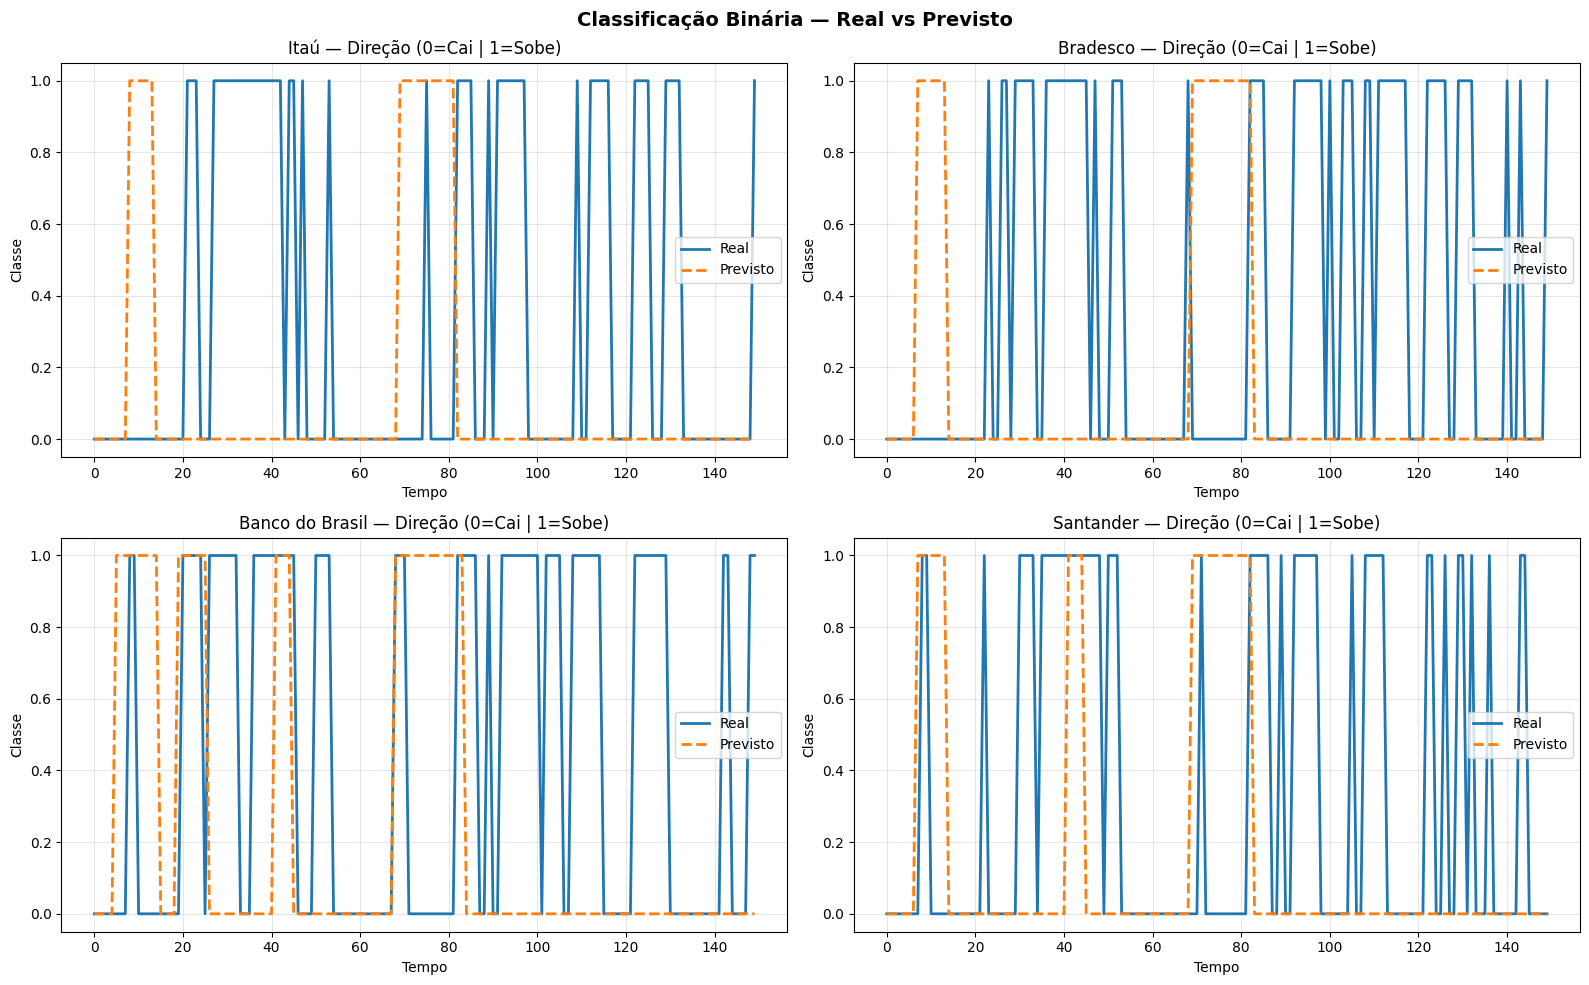

In [13]:
# =============================================================================
# 12. GRÁFICO — CLASSIFICAÇÃO (REAL vs PREVISTO)
# =============================================================================

import matplotlib.pyplot as plt

nomes_bancos = ["Itaú", "Bradesco", "Banco do Brasil", "Santander"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, nome in enumerate(nomes_bancos):

    # Pegando só um trecho pra visualizar melhor
    n = 150

    real = y_test[:, i][-n:]
    pred = y_pred_bin[:, i][-n:]

    axes[i].plot(real, label="Real", linewidth=2)
    axes[i].plot(pred, linestyle="--", label="Previsto", linewidth=2)

    axes[i].set_title(f"{nome} — Direção (0=Cai | 1=Sobe)")
    axes[i].set_xlabel("Tempo")
    axes[i].set_ylabel("Classe")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle("Classificação Binária — Real vs Previsto", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('\nMétricas de Avaliação por Banco (Classificação Binária):\n')

nomes_bancos = ["Itaú", "Bradesco", "Banco do Brasil", "Santander"]

for i, nome in enumerate(nomes_bancos):
    # Acurácia (Accuracy): Proporção de previsões corretas (verdadeiros positivos e verdadeiros negativos) em relação ao total.
    acc = np.mean(y_pred_bin[:, i] == y_test[:, i]) * 100
    # Precisão (Precision): Proporção de verdadeiros positivos entre todas as previsões positivas.
    precision = precision_score(y_test[:, i], y_pred_bin[:, i]) * 100
    # Recall (Revocação/Sensibilidade): Proporção de verdadeiros positivos entre todas as instâncias realmente positivas.
    recall = recall_score(y_test[:, i], y_pred_bin[:, i]) * 100
    # F1-Score: Média harmônica da Precisão e do Recall, útil para equilibrar ambas as métricas.
    f1 = f1_score(y_test[:, i], y_pred_bin[:, i]) * 100

    print(f"--- {nome} ---")
    print(f"Acurácia: {acc:.2f}%")
    print(f"Precisão: {precision:.2f}%")
    print(f"Recall:   {recall:.2f}%")
    print(f"F1-Score: {f1:.2f}%")


Métricas de Avaliação por Banco (Classificação Binária):

--- Itaú ---
Acurácia: 65.83%
Precisão: 40.00%
Recall:   18.67%
F1-Score: 25.45%
--- Bradesco ---
Acurácia: 57.92%
Precisão: 31.11%
Recall:   16.67%
F1-Score: 21.71%
--- Banco do Brasil ---
Acurácia: 56.25%
Precisão: 44.78%
Recall:   30.61%
F1-Score: 36.36%
--- Santander ---
Acurácia: 60.83%
Precisão: 39.58%
Recall:   22.62%
F1-Score: 28.79%


### Explicação das Métricas de Avaliação

Após o treinamento e avaliação do modelo LSTM para a classificação binária da direção dos preços, foram calculadas as seguintes métricas de avaliação para cada um dos bancos:

*   **Acurácia (Accuracy)**: Representa a proporção de previsões corretas (tanto de alta quanto de baixa) em relação ao número total de previsões. Uma acurácia de 65.83% para o Itaú, por exemplo, significa que o modelo previu corretamente a direção do preço em aproximadamente 66% das vezes.

*   **Precisão (Precision)**: Foca nos casos em que o modelo previu que o preço iria subir (classe positiva). A precisão mede a proporção de previsões positivas que estavam de fato corretas. Uma precisão baixa pode indicar que o modelo está fazendo muitas previsões otimistas falsas (Falsos Positivos).

*   **Recall (Revocação / Sensibilidade)**: Foca nos casos em que o preço realmente subiu (instâncias positivas reais). O recall mede a proporção de todas as ocorrências reais de alta que o modelo conseguiu identificar corretamente. Um recall baixo pode indicar que o modelo está perdendo muitas oportunidades reais de alta (Falsos Negativos).

*   **F1-Score**: É a média harmônica da Precisão e do Recall. Ele busca um equilíbrio entre essas duas métricas, sendo especialmente útil em cenários onde há um desequilíbrio significativo entre as classes. Um F1-Score alto indica que o modelo tem um bom desempenho tanto em evitar falsos positivos quanto em evitar falsos negativos.